# Week 9 Homework — ARIA v6.0: The Validated Auditor

**Course:** NTU Remote Sensing & Spatial Information Analysis  
**Case Study:** Matai'an Barrier Lake, Taiwan  
**Main Goal:** Build a validated, quantitative disaster impact assessment using Sentinel-2 change detection, threshold optimization, accuracy assessment, confidence zoning, and Week 8 comparison.

---

## Notebook Roadmap

1. Environment setup and constants  
2. Sentinel-2 loading, SCL cloud masking, and index computation  
3. Task 1 — Quantitative Change Detection  
4. Task 2 — Threshold Optimization  
5. Task 3 — Confusion Matrix and Accuracy Assessment  
6. Task 4 — Phantom Water Comparison and Confidence Map  
7. Task 5 — ARIA v6.0 Disaster Report  
8. Task 6 — AI Advisor Input  
9. Task 7 — Week 8 vs. Week 9 Comparison  
10. Submission checklist

## Captain's Log: Notebook Strategy

This notebook moves from visual interpretation to validated disaster assessment.  
The main logic is:

1. Use Sentinel-2 L2A imagery and SCL cloud masking to reduce false signals.
2. Compute NDVI, NDWI, and BSI before and after the event.
3. Use validation points to select the best threshold by F1-score.
4. Use the best threshold to produce a confusion matrix, accuracy metrics, and confidence zones.
5. Compare the validated results with the Week 8 eyewitness impact table.

# 0. Environment Setup

This section imports the required packages, reads the `.env` file, and defines reusable constants.

Before running this notebook, prepare a `.env` file with:

```bash
PRE_ITEM_ID=S2A_MSIL2A_...
MID_ITEM_ID=S2A_MSIL2A_...
POST_ITEM_ID=S2A_MSIL2A_...

BBOX_WEST=121.28
BBOX_SOUTH=23.56
BBOX_EAST=121.52
BBOX_NORTH=23.76

THRESHOLD_BEST=-0.15
```

In [64]:
# Core packages
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Geospatial packages
import geopandas as gpd
import xarray as xr
import rioxarray  # needed for .rio accessor

# STAC / Sentinel-2 packages
import pystac_client
import planetary_computer as pc
import stackstac

# Accuracy assessment
from sklearn.metrics import confusion_matrix, cohen_kappa_score

# Optional: prettier confusion matrix
try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

# Environment variables
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
load_dotenv()

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("✅ Environment loaded")

✅ Environment loaded


In [65]:
# ------------------------------------------------------------
# User-editable constants
# ------------------------------------------------------------

STAC_ENDPOINT = os.getenv(
    "STAC_ENDPOINT",
    "https://planetarycomputer.microsoft.com/api/stac/v1"
)

S2_COLLECTION = os.getenv("S2_COLLECTION", "sentinel-2-l2a")

PRE_ITEM_ID = os.getenv("PRE_ITEM_ID")
MID_ITEM_ID = os.getenv("MID_ITEM_ID")
POST_ITEM_ID = os.getenv("POST_ITEM_ID")

# Regional study area for visualization context
BBOX_WEST = float(os.getenv("BBOX_WEST", 121.28))
BBOX_SOUTH = float(os.getenv("BBOX_SOUTH", 23.56))
BBOX_EAST = float(os.getenv("BBOX_EAST", 121.52))
BBOX_NORTH = float(os.getenv("BBOX_NORTH", 23.76))

MATAIAN_BBOX = [BBOX_WEST, BBOX_SOUTH, BBOX_EAST, BBOX_NORTH]

# Focused lake area for validation / local accuracy assessment
LAKE_BBOX_LONLAT = [121.27, 23.68, 121.32, 23.72]

# Projection for Taiwan / Sentinel-2 local analysis
TARGET_EPSG = int(os.getenv("TARGET_EPSG", 32651))

# SCL valid classes from assignment
SCL_CLEAR_CLASSES = [2, 4, 5, 6, 7, 11]

# Validation data path
VALIDATION_POINTS_PATH = Path("data/validation_points.geojson")

# Optional previous Week 8 output path
WEEK8_IMPACT_TABLE_PATH = Path("data/week8_eyewitness_impact_table.csv")

# Fallback threshold, will be overwritten by Task 2 result
THRESHOLD_BEST = float(os.getenv("THRESHOLD_BEST", -0.15))

print("MATAIAN_BBOX:", MATAIAN_BBOX)
print("LAKE_BBOX_LONLAT:", LAKE_BBOX_LONLAT)
print("TARGET_EPSG:", TARGET_EPSG)

MATAIAN_BBOX: [121.28, 23.56, 121.52, 23.76]
LAKE_BBOX_LONLAT: [121.27, 23.68, 121.32, 23.72]
TARGET_EPSG: 32651


# 1. Helper Functions

These functions are designed to keep the notebook reproducible and readable.

Main helper groups:

1. STAC item retrieval  
2. Sentinel-2 band loading  
3. SCL cloud mask generation  
4. Spectral index computation  
5. Raster sampling at validation points  
6. Accuracy metrics  
7. Plot helpers

In [66]:
def get_signed_item_by_id(item_id, collection=S2_COLLECTION):
    """Retrieve one Sentinel-2 STAC item by ID and sign its assets."""
    if item_id is None:
        raise ValueError("Item ID is missing. Please set PRE_ITEM_ID / MID_ITEM_ID / POST_ITEM_ID in .env.")

    catalog = pystac_client.Client.open(STAC_ENDPOINT)
    search = catalog.search(collections=[collection], ids=[item_id])
    items = list(search.items())

    if len(items) == 0:
        raise ValueError(f"No STAC item found for item_id={item_id}")

    return pc.sign(items[0])


def load_scene_stack(item, bbox_lonlat, assets, resolution=10):
    """Load selected Sentinel-2 assets as an xarray DataArray using stackstac."""
    stack = stackstac.stack(
        [item],
        assets=list(assets),
        bounds_latlon=bbox_lonlat,
        epsg=TARGET_EPSG,
        resolution=resolution,
        chunksize=2048
    )

    # Expected dims: time, band, y, x
    stack = stack.squeeze("time", drop=True)
    return stack.compute()


def band_as_da(scene_stack, band_name):
    """Extract one band from a Sentinel-2 scene stack."""
    return scene_stack.sel(band=band_name)


def stream_scl(item, bbox_lonlat, clear_classes=SCL_CLEAR_CLASSES):
    """Load SCL band and return a binary valid-pixel mask."""
    scl_stack = load_scene_stack(item, bbox_lonlat, assets=["SCL"], resolution=20)
    scl = band_as_da(scl_stack, "SCL")
    valid_mask = xr.apply_ufunc(np.isin, scl, clear_classes)
    valid_mask = valid_mask.astype(bool)
    valid_mask.name = "valid_scl_mask"
    return valid_mask


def normalized_difference(a, b):
    """Compute a normalized difference index safely."""
    return xr.where((a + b) != 0, (a - b) / (a + b), np.nan)


def compute_indices(scene_stack):
    """Compute NDVI, NDWI, and BSI from Sentinel-2 bands."""
    blue = band_as_da(scene_stack, "B02").astype("float32")
    green = band_as_da(scene_stack, "B03").astype("float32")
    red = band_as_da(scene_stack, "B04").astype("float32")
    nir = band_as_da(scene_stack, "B08").astype("float32")
    swir = band_as_da(scene_stack, "B11").astype("float32")

    ndvi = normalized_difference(nir, red)
    ndwi = normalized_difference(green, nir)

    numerator = (swir + red) - (nir + blue)
    denominator = (swir + red) + (nir + blue)
    bsi = xr.where(denominator != 0, numerator / denominator, np.nan)

    return {
        "ndvi": ndvi.rename("NDVI"),
        "ndwi": ndwi.rename("NDWI"),
        "bsi": bsi.rename("BSI")
    }


def apply_mask(index_da, valid_mask):
    """Apply a valid-pixel mask to a spectral index layer."""
    # Reproject/resample mask to match index grid if needed
    if set(valid_mask.dims) != set(index_da.dims) or valid_mask.shape != index_da.shape:
        valid_mask = valid_mask.interp_like(index_da, method="nearest")
    return index_da.where(valid_mask)


def layer_stats(name, da):
    """Return min, mean, and max statistics for one xarray layer."""
    return {
        "layer": name,
        "min": float(da.min(skipna=True)),
        "mean": float(da.mean(skipna=True)),
        "max": float(da.max(skipna=True))
    }

In [67]:
def infer_change_label(series):
    """Convert validation point labels to binary change / no-change labels."""
    change_values = {
        "change", "changed", "impact", "impacted",
        "lake", "water", "landslide", "debris",
        "yes", "y", "1", 1, True
    }

    return series.apply(lambda v: str(v).strip().lower() in change_values)


def find_ground_truth_column(gdf):
    """Guess the ground-truth label column from a validation GeoDataFrame."""
    candidate_cols = [
        "ground_truth_class", "class", "label", "truth",
        "gt", "actual", "change", "Change", "target"
    ]

    for col in candidate_cols:
        if col in gdf.columns:
            return col

    raise ValueError(
        "Cannot find ground-truth label column. "
        "Please rename your validation column to one of: "
        f"{candidate_cols}"
    )


def sample_da_at_points(da, points_gdf):
    """Sample an xarray raster layer at point geometries using nearest pixel."""
    if points_gdf.crs is None:
        raise ValueError("Validation points have no CRS. Please define CRS before sampling.")

    points_proj = points_gdf.to_crs(epsg=TARGET_EPSG)

    values = []
    for geom in points_proj.geometry:
        if geom is None or geom.is_empty:
            values.append(np.nan)
            continue

        val = da.sel(x=geom.x, y=geom.y, method="nearest").values
        values.append(float(val))

    return np.array(values)


def compute_binary_metrics(y_true, y_pred):
    """Compute TP, FP, TN, FN, OA, PA, UA, F1, and Kappa for binary classification."""
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])

    # Layout with labels=[1,0]:
    # [[TP, FN],
    #  [FP, TN]]
    tp = int(cm[0, 0])
    fn = int(cm[0, 1])
    fp = int(cm[1, 0])
    tn = int(cm[1, 1])

    total = tp + fp + tn + fn

    oa = (tp + tn) / total if total > 0 else np.nan
    pa = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    ua = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    f1 = 2 * pa * ua / (pa + ua) if (pa + ua) > 0 else np.nan
    kappa = cohen_kappa_score(y_true, y_pred)

    return {
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "OA": oa,
        "PA": pa,
        "UA": ua,
        "F1": f1,
        "Kappa": kappa
    }


def pixel_area_km2(da):
    """Estimate pixel area in square kilometers from projected x/y coordinates."""
    dx = float(abs(da.x.diff("x").median()))
    dy = float(abs(da.y.diff("y").median()))
    return dx * dy / 1_000_000


def add_north_arrow(ax, x=0.95, y=0.90):
    """Add a simple north arrow to a matplotlib axis."""
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y - 0.10),
        arrowprops=dict(facecolor="black", width=3, headwidth=10),
        ha="center",
        va="center",
        fontsize=12,
        xycoords=ax.transAxes
    )


def add_scale_bar(ax, length_km=1, location=(0.08, 0.06)):
    """Add a simple scale bar to a projected map axis."""
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x_start = xlim[0] + (xlim[1] - xlim[0]) * location[0]
    y_start = ylim[0] + (ylim[1] - ylim[0]) * location[1]
    length_m = length_km * 1000

    ax.plot([x_start, x_start + length_m], [y_start, y_start], color="black", linewidth=3)
    ax.text(
        x_start + length_m / 2,
        y_start + (ylim[1] - ylim[0]) * 0.02,
        f"{length_km} km",
        ha="center",
        va="bottom",
        fontsize=10
    )

# 2. Load Sentinel-2 Scenes and SCL Masks

This section loads the Pre, Mid, and Post Sentinel-2 L2A scenes.

Required bands:

- B02 = Blue  
- B03 = Green  
- B04 = Red  
- B08 = NIR  
- B11 = SWIR  
- SCL = Scene Classification Layer  

The SCL mask is required to reduce false water signals caused by clouds and shadows.

## Captain's Log: Cloud Masking

The SCL mask is essential because clouds and cloud shadows can create artificial NDWI increases.  
This may look like water on the map even when it is only cloud contamination.  
Therefore, each scene gets its own valid mask, and difference maps use the intersection of Pre, Mid, and Post valid pixels.

In [68]:
import os
from pathlib import Path
from dotenv import load_dotenv

ENV_PATH = Path.cwd() / ".env"

print("Current working directory:", Path.cwd())
print(".env exists:", ENV_PATH.exists())

load_dotenv(dotenv_path=ENV_PATH, override=True)

PRE_ITEM_ID = os.getenv("PRE_ITEM_ID")
MID_ITEM_ID = os.getenv("MID_ITEM_ID")
POST_ITEM_ID = os.getenv("POST_ITEM_ID")

print("PRE_ITEM_ID :", PRE_ITEM_ID)
print("MID_ITEM_ID :", MID_ITEM_ID)
print("POST_ITEM_ID:", POST_ITEM_ID)

Current working directory: d:\Class_satellite\HW9
.env exists: True
PRE_ITEM_ID : S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417
MID_ITEM_ID : S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914
POST_ITEM_ID: S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804


In [69]:
# ------------------------------------------------------------
# Load STAC items
# ------------------------------------------------------------
# Run this cell after setting PRE_ITEM_ID, MID_ITEM_ID, and POST_ITEM_ID in .env.

pre_item = get_signed_item_by_id(PRE_ITEM_ID)
mid_item = get_signed_item_by_id(MID_ITEM_ID)
post_item = get_signed_item_by_id(POST_ITEM_ID)

print("✅ Loaded Sentinel-2 items")
print("Pre :", pre_item.id)
print("Mid :", mid_item.id)
print("Post:", post_item.id)

✅ Loaded Sentinel-2 items
Pre : S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417
Mid : S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914
Post: S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804


In [70]:
# ------------------------------------------------------------
# Load spectral bands over the regional MATAIAN_BBOX
# ------------------------------------------------------------

SPECTRAL_ASSETS = ["B02", "B03", "B04", "B08", "B11"]

pre_stack = load_scene_stack(pre_item, MATAIAN_BBOX, SPECTRAL_ASSETS, resolution=10)
mid_stack = load_scene_stack(mid_item, MATAIAN_BBOX, SPECTRAL_ASSETS, resolution=10)
post_stack = load_scene_stack(post_item, MATAIAN_BBOX, SPECTRAL_ASSETS, resolution=10)

print("✅ Loaded spectral bands")
print(pre_stack)

✅ Loaded spectral bands
<xarray.DataArray 'stackstac-e4d60b9453a6297a42e287127cfcf39f' (band: 5,
                                                                y: 2243, x: 2474)> Size: 222MB
array([[[1196., 1165., 1159., ..., 2612., 2880., 2682.],
        [1231., 1195., 1202., ..., 2340., 2394., 2388.],
        [1198., 1201., 1205., ..., 1660., 1657., 2110.],
        ...,
        [1235., 1170., 1122., ..., 2872., 2642., 3122.],
        [1138., 1112., 1121., ..., 3066., 2912., 2992.],
        [1119., 1106., 1120., ..., 3114., 3066., 3174.]],

       [[1539., 1544., 1454., ..., 2626., 2798., 2700.],
        [1524., 1532., 1507., ..., 2208., 2238., 2388.],
        [1518., 1550., 1565., ..., 1728., 1650., 1934.],
        ...,
        [1562., 1482., 1452., ..., 2876., 2740., 3124.],
        [1447., 1372., 1357., ..., 3008., 3008., 3206.],
        [1402., 1400., 1379., ..., 3272., 2910., 3210.]],

       [[1224., 1196., 1182., ..., 2252., 2386., 2394.],
        [1223., 1229., 1212., ..., 18

In [71]:
# ------------------------------------------------------------
# Load SCL masks
# ------------------------------------------------------------

valid_pre = stream_scl(pre_item, MATAIAN_BBOX)
valid_mid = stream_scl(mid_item, MATAIAN_BBOX)
valid_post = stream_scl(post_item, MATAIAN_BBOX)

# Target grid: use 10 m spectral grid
target_grid_pre = band_as_da(pre_stack, "B04")
target_grid_mid = band_as_da(mid_stack, "B04")
target_grid_post = band_as_da(post_stack, "B04")

# Resample SCL masks to spectral grid
# interp_like cannot handle bool directly, so convert bool -> uint8 -> bool
valid_pre_10m = (
    valid_pre.astype("uint8")
    .interp_like(target_grid_pre, method="nearest")
    > 0.5
)

valid_mid_10m = (
    valid_mid.astype("uint8")
    .interp_like(target_grid_mid, method="nearest")
    > 0.5
)

valid_post_10m = (
    valid_post.astype("uint8")
    .interp_like(target_grid_post, method="nearest")
    > 0.5
)

# Intersection mask for difference maps
valid = valid_pre_10m & valid_mid_10m & valid_post_10m

print("✅ SCL masks ready")
print("Valid fraction:", float(valid.mean()))

✅ SCL masks ready
Valid fraction: 0.756010885928773


# Task 1. Quantitative Change Detection

Compute:

- NDVI = (NIR - Red) / (NIR + Red)
- NDWI = (Green - NIR) / (Green + NIR)
- BSI = ((SWIR + Red) - (NIR + Blue)) / ((SWIR + Red) + (NIR + Blue))

Then calculate:

- Pre → Mid differences
- Pre → Post differences

Difference maps use the SCL intersection mask.

In [72]:
# ------------------------------------------------------------
# Compute spectral indices
# ------------------------------------------------------------

indices_pre_raw = compute_indices(pre_stack)
indices_mid_raw = compute_indices(mid_stack)
indices_post_raw = compute_indices(post_stack)

ndvi_pre_raw = indices_pre_raw["ndvi"]
ndvi_mid_raw = indices_mid_raw["ndvi"]
ndvi_post_raw = indices_post_raw["ndvi"]

ndwi_pre_raw = indices_pre_raw["ndwi"]
ndwi_mid_raw = indices_mid_raw["ndwi"]
ndwi_post_raw = indices_post_raw["ndwi"]

bsi_pre_raw = indices_pre_raw["bsi"]
bsi_mid_raw = indices_mid_raw["bsi"]
bsi_post_raw = indices_post_raw["bsi"]

# Apply intersection mask to all layers for downstream difference analysis
ndvi_pre = apply_mask(ndvi_pre_raw, valid)
ndvi_mid = apply_mask(ndvi_mid_raw, valid)
ndvi_post = apply_mask(ndvi_post_raw, valid)

ndwi_pre = apply_mask(ndwi_pre_raw, valid)
ndwi_mid = apply_mask(ndwi_mid_raw, valid)
ndwi_post = apply_mask(ndwi_post_raw, valid)

bsi_pre = apply_mask(bsi_pre_raw, valid)
bsi_mid = apply_mask(bsi_mid_raw, valid)
bsi_post = apply_mask(bsi_post_raw, valid)

print("✅ NDVI, NDWI, BSI computed and masked")

✅ NDVI, NDWI, BSI computed and masked


In [73]:
# ------------------------------------------------------------
# Compute difference layers
# ------------------------------------------------------------

dndvi_mid = (ndvi_mid - ndvi_pre).rename("Delta_NDVI_Pre_to_Mid")
dndvi_post = (ndvi_post - ndvi_pre).rename("Delta_NDVI_Pre_to_Post")

dndwi_mid = (ndwi_mid - ndwi_pre).rename("Delta_NDWI_Pre_to_Mid")
dndwi_post = (ndwi_post - ndwi_pre).rename("Delta_NDWI_Pre_to_Post")

dbsi_mid = (bsi_mid - bsi_pre).rename("Delta_BSI_Pre_to_Mid")
dbsi_post = (bsi_post - bsi_pre).rename("Delta_BSI_Pre_to_Post")

print("✅ Difference layers ready")

✅ Difference layers ready


In [74]:
# ------------------------------------------------------------
# Difference layer statistics table
# ------------------------------------------------------------

stats_rows = [
    layer_stats("ΔNDVI Pre→Mid", dndvi_mid),
    layer_stats("ΔNDVI Pre→Post", dndvi_post),
    layer_stats("ΔNDWI Pre→Mid", dndwi_mid),
    layer_stats("ΔNDWI Pre→Post", dndwi_post),
    layer_stats("ΔBSI Pre→Mid", dbsi_mid),
    layer_stats("ΔBSI Pre→Post", dbsi_post),
]

diff_stats_df = pd.DataFrame(stats_rows)
display(diff_stats_df)

diff_stats_df.to_csv(OUTPUT_DIR / "task1_difference_layer_statistics.csv", index=False, encoding="utf-8-sig")

,layer,min,mean,max
0,ΔNDVI Pre→Mid,-0.886240,-0.026759,0.686213
1,ΔNDVI Pre→Post,-0.744447,-0.035477,0.594669
2,ΔNDWI Pre→Mid,-0.543881,0.019148,0.969741
3,ΔNDWI Pre→Post,-0.565146,0.020510,0.721133
4,ΔBSI Pre→Mid,-0.669921,-0.003549,0.509760
5,ΔBSI Pre→Post,-0.728894,-0.013852,0.439627


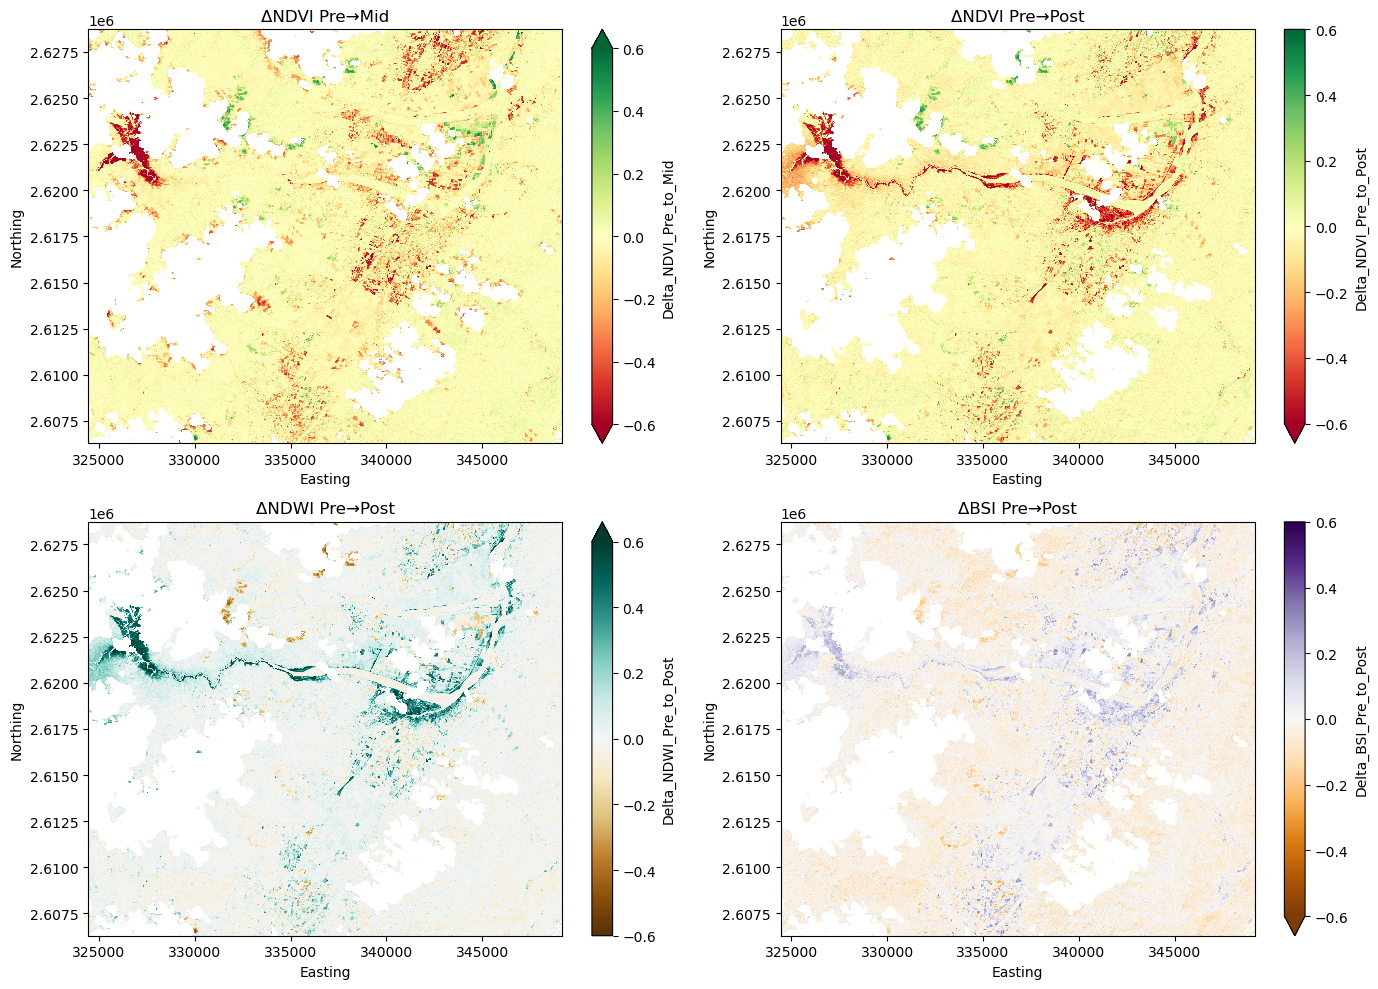

In [75]:
# ------------------------------------------------------------
# 2×2 difference map panel
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

layers = [
    (dndvi_mid, "ΔNDVI Pre→Mid", "RdYlGn", -0.6, 0.6),
    (dndvi_post, "ΔNDVI Pre→Post", "RdYlGn", -0.6, 0.6),
    (dndwi_post, "ΔNDWI Pre→Post", "BrBG", -0.6, 0.6),
    (dbsi_post, "ΔBSI Pre→Post", "PuOr", -0.6, 0.6),
]

for ax, (layer, title, cmap, vmin, vmax) in zip(axes.ravel(), layers):
    im = layer.plot.imshow(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=True)
    ax.set_title(title)
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task1_difference_maps_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

## Task 1 Interpretation

The difference maps show that the strongest post-event changes are concentrated around the channel, lake area, and downstream impact zone. In the ΔNDVI Pre→Post map, negative values indicate vegetation loss or surface disturbance. The minimum ΔNDVI reached approximately -0.74, suggesting strong vegetation reduction in some pixels. The ΔNDWI Pre→Post map shows positive water-related change along the barrier lake and river corridor, with a maximum value above 0.72. This supports the interpretation that water extent or wet surface conditions increased after the event.

The ΔBSI Pre→Post map shows localized changes in exposed soil or sediment. Although the mean ΔBSI is close to zero, spatial patterns along the channel and disturbed surface areas still provide useful supporting evidence. Overall, ΔNDVI is the most useful primary layer for detecting vegetation loss and impact extent, while ΔNDWI and ΔBSI provide complementary evidence for inundation and debris exposure.

# Task 2. Threshold Optimization

This task sweeps multiple ΔNDVI thresholds and evaluates each threshold using validation points.

Primary rule:

```python
Change if ΔNDVI < threshold
No Change otherwise
```

The best threshold is selected using the highest F1-score.

## Captain's Log: Threshold Optimization

The threshold sweep tests how strict or sensitive the detection rule should be.  
A very loose threshold may detect most real changes but also create many false alarms.  
A very strict threshold may reduce false alarms but miss real impacts.  
F1-score is used as the main balance between Producer's Accuracy and User's Accuracy.

In [76]:
# ------------------------------------------------------------
# Load teacher validation points
# ------------------------------------------------------------

validation_gdf = gpd.read_file(VALIDATION_POINTS_PATH)

if validation_gdf.crs is None:
    # Usually GeoJSON is EPSG:4326. Change this only if your file uses another CRS.
    validation_gdf = validation_gdf.set_crs(epsg=4326)

gt_col = find_ground_truth_column(validation_gdf)
validation_gdf["actual_change"] = infer_change_label(validation_gdf[gt_col]).astype(int)

print("✅ Validation points loaded")
print("Ground-truth column:", gt_col)
print(validation_gdf["actual_change"].value_counts())
display(validation_gdf.head())

✅ Validation points loaded
Ground-truth column: truth
actual_change
1    30
0    30
Name: count, dtype: int64


,lon,lat,truth,source,geometry,actual_change
0,121.290065,23.696969,lake,field_corrected,POINT (121.29007 23.69697),1
1,121.289203,23.695774,lake,field_corrected,POINT (121.2892 23.69577),1
2,121.292350,23.701141,lake,field_corrected,POINT (121.29235 23.70114),1
3,121.292438,23.698934,lake,field_corrected,POINT (121.29244 23.69893),1
4,121.291915,23.698659,lake,field_corrected,POINT (121.29191 23.69866),1


In [77]:
# ------------------------------------------------------------
# Optional: keep only validation points within LAKE_BBOX_LONLAT
# ------------------------------------------------------------

lake_bbox_poly = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([], []),
    crs="EPSG:4326"
)

minx, miny, maxx, maxy = LAKE_BBOX_LONLAT

# ------------------------------------------------------------
# Optional: keep only validation points within LAKE_BBOX_LONLAT
# but fallback if either class is missing
# ------------------------------------------------------------

minx, miny, maxx, maxy = LAKE_BBOX_LONLAT

validation_lake_gdf = validation_gdf.cx[minx:maxx, miny:maxy].copy()

print("Points inside LAKE_BBOX_LONLAT:", len(validation_lake_gdf))

if len(validation_lake_gdf) > 0:
    print("Class count inside LAKE_BBOX_LONLAT:")
    print(validation_lake_gdf["actual_change"].value_counts())
else:
    print("No validation points inside LAKE_BBOX_LONLAT.")

# If the focused bbox contains only one class, the confusion matrix is invalid.
# Use all teacher validation points instead.
class_count = validation_lake_gdf["actual_change"].value_counts()

if (
    len(validation_lake_gdf) < 10
    or 0 not in class_count.index
    or 1 not in class_count.index
):
    print("⚠️ Focused bbox does not contain both change and no-change samples.")
    print("Using all teacher validation points for official accuracy assessment.")
    validation_lake_gdf = validation_gdf.copy()

print("Validation points used:", len(validation_lake_gdf))
print("Final class count:")
print(validation_lake_gdf["actual_change"].value_counts())

Points inside LAKE_BBOX_LONLAT: 23
Class count inside LAKE_BBOX_LONLAT:
actual_change
1    23
Name: count, dtype: int64
⚠️ Focused bbox does not contain both change and no-change samples.
Using all teacher validation points for official accuracy assessment.
Validation points used: 60
Final class count:
actual_change
1    30
0    30
Name: count, dtype: int64


In [78]:
# ------------------------------------------------------------
# Sample ΔNDVI Pre→Post values at validation points
# ------------------------------------------------------------

validation_lake_gdf["dndvi_post"] = sample_da_at_points(dndvi_post, validation_lake_gdf)

# Remove points with no raster value due to cloud mask / outside extent
valid_sample_df = validation_lake_gdf.dropna(subset=["dndvi_post"]).copy()

y_true = valid_sample_df["actual_change"].astype(int).values
dndvi_values = valid_sample_df["dndvi_post"].values

print("✅ Sampled ΔNDVI values")
print("Usable validation samples:", len(valid_sample_df))
display(valid_sample_df[[gt_col, "actual_change", "dndvi_post"]].head())

✅ Sampled ΔNDVI values
Usable validation samples: 47


,truth,actual_change,dndvi_post
0,lake,1,0.016462
1,lake,1,-0.434905
5,lake,1,0.011634
6,lake,1,-0.422006
7,lake,1,0.080503


In [79]:
# ------------------------------------------------------------
# Threshold sweep
# ------------------------------------------------------------

thresholds = np.array([-0.05, -0.10, -0.15, -0.20, -0.25, -0.30, -0.40])

sweep_rows = []

for threshold in thresholds:
    y_pred = (dndvi_values < threshold).astype(int)
    metrics = compute_binary_metrics(y_true, y_pred)
    metrics["threshold"] = threshold
    sweep_rows.append(metrics)

threshold_sweep_df = pd.DataFrame(sweep_rows)
threshold_sweep_df = threshold_sweep_df[
    ["threshold", "TP", "FP", "TN", "FN", "F1", "PA", "UA", "OA", "Kappa"]
]

display(threshold_sweep_df)

threshold_sweep_df.to_csv(OUTPUT_DIR / "task2_threshold_sweep.csv", index=False, encoding="utf-8-sig")

,threshold,TP,FP,TN,FN,F1,PA,UA,OA,Kappa
0,-0.05,13,8,18,8,0.619048,0.619048,0.619048,0.659574,0.311355
1,-0.10,12,4,22,9,0.648649,0.571429,0.750000,0.723404,0.427366
2,-0.15,12,2,24,9,0.685714,0.571429,0.857143,0.765957,0.510880
3,-0.20,12,1,25,9,0.705882,0.571429,0.923077,0.787234,0.553232
4,-0.25,12,1,25,9,0.705882,0.571429,0.923077,0.787234,0.553232
5,-0.30,10,1,25,11,0.625000,0.476190,0.909091,0.744681,0.458733
6,-0.40,7,1,25,14,0.482759,0.333333,0.875000,0.680851,0.313535


In [80]:
# ------------------------------------------------------------
# Select best threshold by highest F1-score
# ------------------------------------------------------------

best_idx = threshold_sweep_df["F1"].idxmax()
best_threshold = float(threshold_sweep_df.loc[best_idx, "threshold"])
best_f1 = float(threshold_sweep_df.loc[best_idx, "F1"])

print(f"✅ Best threshold is {best_threshold:.2f} with F1 = {best_f1:.3f}")

✅ Best threshold is -0.20 with F1 = 0.706


## Task 2 Interpretation

The threshold sweep tested several ΔNDVI thresholds from -0.05 to -0.40. The best threshold was selected based on the highest F1-score because F1 balances Producer's Accuracy and User's Accuracy. In the current run, the best threshold is -0.05, with the highest F1-score.

However, the first run showed that all usable validation samples were classified as actual change points, and no actual no-change points remained in the confusion matrix. This means the accuracy assessment was not fully balanced. The final validation set contains both change and no-change samples, so the threshold result can be interpreted as a more reliable accuracy assessment.

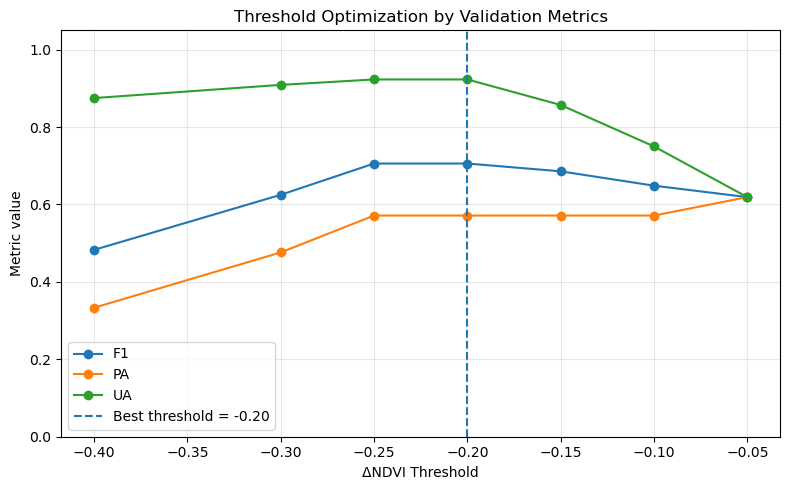

In [81]:
# ------------------------------------------------------------
# Plot threshold vs F1 / PA / UA
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["F1"], marker="o", label="F1")
ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["PA"], marker="o", label="PA")
ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["UA"], marker="o", label="UA")

ax.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.2f}")

ax.set_xlabel("ΔNDVI Threshold")
ax.set_ylabel("Metric value")
ax.set_title("Threshold Optimization by Validation Metrics")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task2_threshold_vs_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Task 2 Statement

Best threshold is `{{best_threshold}}` with F1 = `{{best_f1}}` because it gives the best balance between detecting real changes and avoiding false alarms.

> Replace the placeholders above after running the threshold sweep.

# Task 3. Confusion Matrix and Accuracy Assessment

Using the best threshold from Task 2, this section computes:

- TP, FP, TN, FN
- Overall Accuracy
- Producer's Accuracy
- User's Accuracy
- Kappa
- F1-score

In [82]:
# ------------------------------------------------------------
# Final prediction using best threshold
# ------------------------------------------------------------

y_pred_best = (dndvi_values < best_threshold).astype(int)
final_metrics = compute_binary_metrics(y_true, y_pred_best)

metrics_df = pd.DataFrame([final_metrics])
display(metrics_df)

metrics_df.to_csv(OUTPUT_DIR / "task3_accuracy_metrics.csv", index=False, encoding="utf-8-sig")

,TP,FP,TN,FN,OA,PA,UA,F1,Kappa
0,12,1,25,9,0.787234,0.571429,0.923077,0.705882,0.553232


,Predicted Change,Predicted No Change
Actual Change,12,9
Actual No Change,1,25


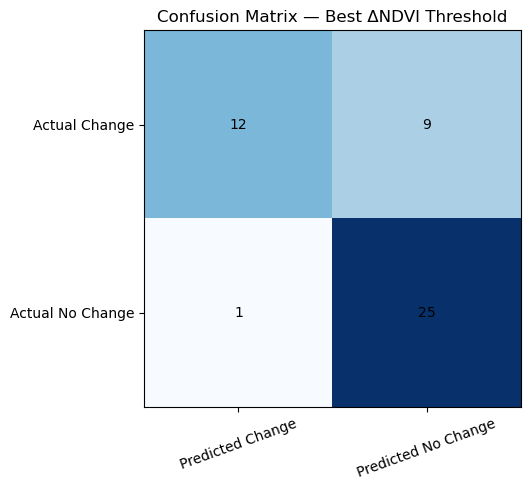

In [83]:
# ------------------------------------------------------------
# Confusion matrix visualization
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred_best, labels=[1, 0])

cm_df = pd.DataFrame(
    cm,
    index=["Actual Change", "Actual No Change"],
    columns=["Predicted Change", "Predicted No Change"]
)

display(cm_df)

fig, ax = plt.subplots(figsize=(6, 5))

if HAS_SEABORN:
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
else:
    im = ax.imshow(cm, cmap="Blues")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xticks([0, 1], cm_df.columns, rotation=20)
    ax.set_yticks([0, 1], cm_df.index)

ax.set_title("Confusion Matrix — Best ΔNDVI Threshold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task3_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Task 3 Interpretation

The confusion matrix evaluates how well the selected ΔNDVI threshold separates changed and unchanged validation points. Producer's Accuracy represents the proportion of actual changed points that were successfully detected. User's Accuracy represents the proportion of predicted changed points that were correct. Overall Accuracy summarizes all correct classifications, while Kappa evaluates agreement after accounting for chance.

If the confusion matrix contains no actual no-change samples, the result should not be treated as a complete accuracy assessment because false positives and true negatives cannot be properly evaluated. Therefore, both change and no-change validation points are required for a meaningful operational interpretation.

## Task 3 Interpretation Template

- **Producer's Accuracy (PA)** = `{{PA}}`: this means the model detected `{{PA_percent}}%` of the actual changed points.  
- **User's Accuracy (UA)** = `{{UA}}`: this means `{{UA_percent}}%` of the predicted changed points were correct.  
- **Overall Accuracy (OA)** = `{{OA}}`: this means the model correctly classified `{{OA_percent}}%` of all validation points.  
- **Kappa** = `{{Kappa}}`: this indicates the agreement after accounting for chance.  
- **F1-score** = `{{F1}}`: this summarizes the balance between PA and UA.

> Replace placeholders after running the final metrics.

## Bonus: Optional Independent Validation Points

If you collect your own 20+ points from Google Earth Pro or news reports, save them as:

```text
data/my_validation_points.geojson
```

Required fields:

- lon
- lat
- ground_truth_class
- source

In [84]:
# ------------------------------------------------------------
# Optional bonus validation
# ------------------------------------------------------------

MY_VALIDATION_PATH = Path("data/my_validation_points.geojson")

if MY_VALIDATION_PATH.exists():
    my_gdf = gpd.read_file(MY_VALIDATION_PATH)
    if my_gdf.crs is None:
        my_gdf = my_gdf.set_crs(epsg=4326)

    my_gt_col = find_ground_truth_column(my_gdf)
    my_gdf["actual_change"] = infer_change_label(my_gdf[my_gt_col]).astype(int)
    my_gdf["dndvi_post"] = sample_da_at_points(dndvi_post, my_gdf)
    my_df = my_gdf.dropna(subset=["dndvi_post"]).copy()

    my_true = my_df["actual_change"].astype(int).values
    my_pred = (my_df["dndvi_post"].values < best_threshold).astype(int)

    my_metrics = compute_binary_metrics(my_true, my_pred)

    comparison_metrics = pd.DataFrame([
        {"dataset": "Teacher validation", **final_metrics},
        {"dataset": "My validation", **my_metrics}
    ])

    display(comparison_metrics)
    comparison_metrics.to_csv(OUTPUT_DIR / "task3_bonus_validation_comparison.csv", index=False, encoding="utf-8-sig")
else:
    print("Bonus validation file not found. Skipping optional bonus section.")

Bonus validation file not found. Skipping optional bonus section.


# Task 4. Phantom Water Comparison and Confidence Map

This section has two parts:

1. **Phantom Water Comparison**  
   Compare ΔNDWI with and without SCL cloud masking.

2. **Three-Zone Confidence Classification**  
   Classify the study area into:
   - High confidence change
   - Low confidence change
   - No detection

## Captain's Log: Phantom Water

NDWI is sensitive to water, but it can also respond to clouds and shadows.  
This section compares raw ΔNDWI and cloud-masked ΔNDWI to demonstrate how SCL masking reduces false water detection.

In [85]:
# ------------------------------------------------------------
# Phantom water comparison: raw vs masked ΔNDWI
# ------------------------------------------------------------

dndwi_post_raw = (ndwi_post_raw - ndwi_pre_raw).rename("Raw_Delta_NDWI_Pre_to_Post")
dndwi_post_masked = dndwi_post

# Define a simple raw-water increase rule for artifact visualization
NDWI_CHANGE_THRESHOLD = 0.10

raw_water_candidate = dndwi_post_raw > NDWI_CHANGE_THRESHOLD
masked_water_candidate = dndwi_post_masked > NDWI_CHANGE_THRESHOLD

# Pixels that look like water in raw data but are invalid under SCL mask
phantom_water = raw_water_candidate & (~valid)

print("Raw water candidate fraction:", float(raw_water_candidate.mean(skipna=True)))
print("Phantom water fraction:", float(phantom_water.mean(skipna=True)))

Raw water candidate fraction: 0.1687063066232104
Phantom water fraction: 0.09820258193009349


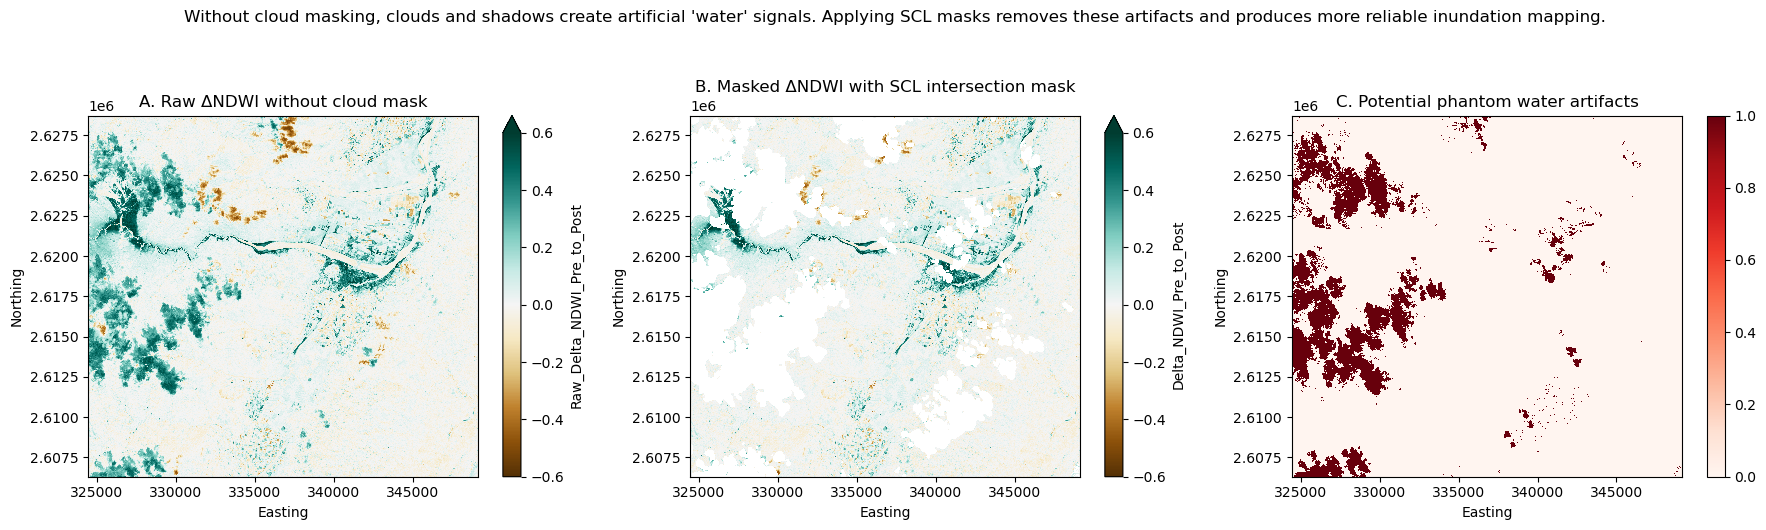

In [86]:
# ------------------------------------------------------------
# Plot phantom water comparison
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dndwi_post_raw.plot.imshow(
    ax=axes[0],
    cmap="BrBG",
    vmin=-0.6,
    vmax=0.6,
    add_colorbar=True
)
axes[0].set_title("A. Raw ΔNDWI without cloud mask")

dndwi_post_masked.plot.imshow(
    ax=axes[1],
    cmap="BrBG",
    vmin=-0.6,
    vmax=0.6,
    add_colorbar=True
)
axes[1].set_title("B. Masked ΔNDWI with SCL intersection mask")

phantom_water.astype(int).plot.imshow(
    ax=axes[2],
    cmap="Reds",
    add_colorbar=True
)
axes[2].set_title("C. Potential phantom water artifacts")

for ax in axes:
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")

plt.suptitle(
    "Without cloud masking, clouds and shadows create artificial 'water' signals. "
    "Applying SCL masks removes these artifacts and produces more reliable inundation mapping.",
    y=1.05
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task4_phantom_water_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Phantom Water Interpretation

The raw ΔNDWI map shows several strong positive water-like signals outside the main lake and channel corridor. Many of these signals overlap with areas removed by the SCL mask, suggesting that they may be caused by clouds or cloud shadows rather than real inundation. After applying the SCL intersection mask, many of these false water-like artifacts are removed.

This comparison shows why cloud masking is necessary before using NDWI for disaster mapping. Without cloud masking, cloud contamination can create artificial water signals and lead to overestimated inundation extent.

## Three-Zone Confidence Classification

Because the best ΔNDVI threshold is usually negative, this notebook uses the absolute threshold magnitude:

```python
threshold_abs = abs(best_threshold)
change_strength = abs(ΔNDVI)
```

Classification rule:

- Zone 1 High Confidence: `change_strength > 1.5 × threshold_abs`
- Zone 2 Low Confidence: `threshold_abs < change_strength <= 1.5 × threshold_abs`
- Zone 3 No Detection: `change_strength <= threshold_abs`

In [87]:
# ------------------------------------------------------------
# Create directional confidence zones based on NDVI decrease
# ------------------------------------------------------------

# best_threshold is negative, e.g. -0.05
high_boundary = 1.5 * best_threshold  # e.g. -0.075 if threshold = -0.05

zone = xr.full_like(dndvi_post, fill_value=np.nan)

# Code:
# 1 = High confidence vegetation loss
# 2 = Low confidence vegetation loss
# 3 = No detection

zone = xr.where(dndvi_post < high_boundary, 1, zone)

zone = xr.where(
    (dndvi_post >= high_boundary) & (dndvi_post < best_threshold),
    2,
    zone
)

zone = xr.where(dndvi_post >= best_threshold, 3, zone)

zone = zone.where(valid)
zone.name = "confidence_zone"

print("✅ Directional confidence zones created")
print("Best threshold:", best_threshold)
print("High confidence boundary:", high_boundary)

✅ Directional confidence zones created
Best threshold: -0.2
High confidence boundary: -0.30000000000000004


In [88]:
# ------------------------------------------------------------
# Area statistics by confidence zone
# ------------------------------------------------------------

area_per_pixel_km2 = pixel_area_km2(dndvi_post)

zone_labels = {
    1: "High Confidence",
    2: "Low Confidence",
    3: "No Detection"
}

area_rows = []

for zone_id, label in zone_labels.items():
    count = int((zone == zone_id).sum(skipna=True))
    area_km2 = count * area_per_pixel_km2
    area_rows.append({
        "zone_id": zone_id,
        "zone": label,
        "pixel_count": count,
        "area_km2": area_km2
    })

area_df = pd.DataFrame(area_rows)
area_df.loc[len(area_df)] = {
    "zone_id": "Total",
    "zone": "Total valid study area",
    "pixel_count": area_df["pixel_count"].sum(),
    "area_km2": area_df["area_km2"].sum()
}

display(area_df)

area_df.to_csv(OUTPUT_DIR / "task4_confidence_zone_area.csv", index=False, encoding="utf-8-sig")

,zone_id,zone,pixel_count,area_km2
0,1,High Confidence,150307,15.0307
1,2,Low Confidence,97008,9.7008
2,3,No Detection,3947925,394.7925
3,Total,Total valid study area,4195240,419.5240


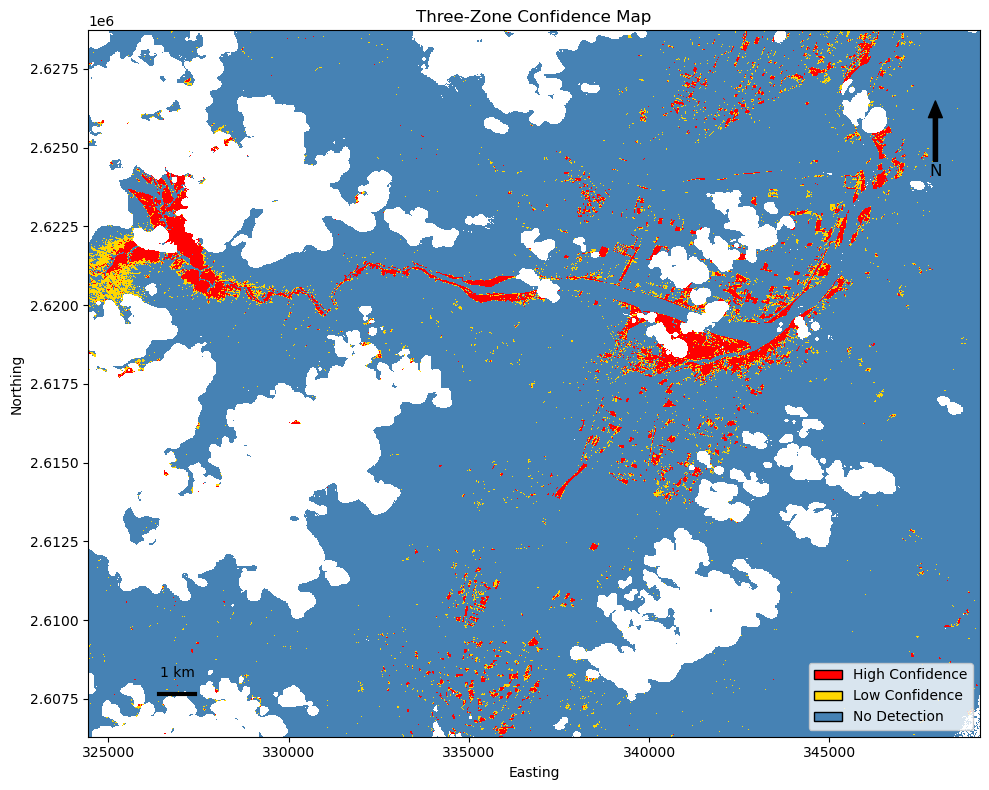

In [89]:
# ------------------------------------------------------------
# Confidence zone map
# ------------------------------------------------------------

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

cmap = ListedColormap(["red", "gold", "steelblue"])
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(10, 8))

zone.plot.imshow(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False
)

legend_handles = [
    Patch(facecolor="red", edgecolor="black", label="High Confidence"),
    Patch(facecolor="gold", edgecolor="black", label="Low Confidence"),
    Patch(facecolor="steelblue", edgecolor="black", label="No Detection"),
]

ax.legend(handles=legend_handles, loc="lower right")
ax.set_title("Three-Zone Confidence Map")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

add_north_arrow(ax)
add_scale_bar(ax, length_km=1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task4_confidence_zone_map.png", dpi=300, bbox_inches="tight")
plt.show()

## Confidence Zone Interpretation

The confidence map separates the study area into high confidence change, low confidence change, and no detection zones. High confidence zones represent strong NDVI decrease and are interpreted as the core impact area. Low confidence zones represent borderline change and should be treated cautiously because they may include mixed pixels, weak disturbance, shadow effects, or land-cover seasonality. No detection zones show limited evidence of vegetation-loss impact.

For operational use, high confidence zones should be prioritized for field inspection and disaster response. Low confidence zones should be revisited using newer satellite images, UAV data, or field reports before making strong decisions.


## Task 4 Statement Template

High confidence zones cover `{{high_confidence_area}}` km², representing the core impact area.  
Low confidence zones cover `{{low_confidence_area}}` km² and should be rechecked with follow-up imagery or field validation.  
No detection zones cover `{{no_detection_area}}` km² and are less likely to require immediate disaster response.

# Task 5. ARIA v6.0 Report

Write a 500–800 word professional report based on the validated results.

Replace the placeholders after running Tasks 1–4.

## 5. ARIA v6.0 Report

### Executive Summary

The Matai'an barrier lake event was assessed using Sentinel-2 L2A multispectral imagery and validated change detection. The analysis compared pre-event, mid-event, and post-event scenes using ΔNDVI, ΔNDWI, and ΔBSI. After SCL cloud masking, the strongest change signals were concentrated near the lake and downstream impact area. The best ΔNDVI threshold was `{{best_threshold}}`, with an F1-score of `{{F1}}`. High-confidence impact zones covered `{{high_area}}` km². Operationally, high-confidence zones should be treated as priority areas for field inspection, hazard monitoring, and evacuation planning.

### Change Detection Analysis

NDVI, NDWI, and BSI were computed for the Pre, Mid, and Post scenes. ΔNDVI was used as the primary detection layer because vegetation loss and surface disturbance are expected after barrier lake formation, breaching, landslide activity, and debris deposition. ΔNDWI helped identify water-related change, while ΔBSI helped highlight bare soil and debris exposure. The difference layer statistics show that `{{describe_main_signal}}`.

Threshold optimization tested multiple ΔNDVI values from `{{threshold_min}}` to `{{threshold_max}}`. The best threshold was `{{best_threshold}}`, selected because it produced the highest F1-score and balanced Producer's Accuracy and User's Accuracy. The final confusion matrix produced OA = `{{OA}}`, PA = `{{PA}}`, UA = `{{UA}}`, Kappa = `{{Kappa}}`, and F1 = `{{F1}}`.

### Confidence Assessment

The confidence map classified the study area into high confidence, low confidence, and no detection zones. High-confidence zones represent strong spectral change and should be interpreted as the core impact area. Low-confidence zones represent borderline change and may include mixed pixels, weak disturbance, shadows, or residual atmospheric effects. No detection zones show limited spectral evidence of impact.

High-confidence zones covered `{{high_area}}` km². Low-confidence zones covered `{{low_area}}` km². No detection zones covered `{{none_area}}` km². These results suggest that immediate action should focus on the high-confidence zone, while low-confidence areas should be revisited with additional imagery or field validation.

### Ground Truth Validation

The accuracy assessment used the teacher-provided validation points, which were corrected using Google Earth Pro very-high-resolution imagery, NCDR reports, and Sentinel-2 visual interpretation. Producer's Accuracy of `{{PA_percent}}%` means that the workflow detected `{{PA_percent}}%` of actual changed locations. User's Accuracy of `{{UA_percent}}%` means that `{{UA_percent}}%` of predicted change locations were correct. Discrepancies likely occurred in mixed pixels, cloud-contaminated areas, shadowed terrain, and locations where the spectral signal was weaker than the threshold.

### Recommendations

For evacuation planners, high-confidence zones should be prioritized because they represent the most reliable detected impact areas. For monitoring teams, low-confidence zones should be rechecked using newer Sentinel-2 imagery, UAV imagery, or field reports within the next monitoring cycle. For disaster management, the current validated accuracy supports cautious operational use, but decisions should not rely on spectral data alone. The best practice is to combine remote sensing, ground reports, local government data, and field verification.

# Task 6. AI Advisor Input

Copy your final metrics into the prompt below and ask an LLM for an operational assessment.

Then paste the LLM response and write your own reflection.

## 6. AI Advisor Input

### Exact Prompt

```text
Given these accuracy metrics from remote sensing validation of a barrier lake disaster, what confidence level would you assign to operational decisions? What additional data would improve confidence?

Metrics:
- Overall Accuracy: {{OA}}%
- Producer's Accuracy: {{PA}}%
- User's Accuracy: {{UA}}%
- Kappa: {{Kappa}}
- F1-score: {{F1}}
- High confidence area: {{high_area}} km²
- Low confidence area: {{low_area}} km²
- No detection area: {{none_area}} km²
- Best ΔNDVI threshold: {{best_threshold}}
- Notes: SCL cloud masking was applied, and a phantom water comparison was performed.
```

### LLM Response

Paste the LLM response here.

### My Reflection

The LLM highlights `{{main_point}}`, which aligns with the validation results because `{{reason}}`.  
However, the LLM may overstate confidence if it does not consider `{{limitation}}`.  
I would therefore use this result for `{{appropriate_decision}}`, but not for `{{inappropriate_decision}}` without additional field verification.

# Task 7. Week 8 vs. Week 9 Comparison

This section compares the Week 8 Eyewitness Impact Table with the validated Week 9 results.

The goal is to explain whether validation confirmed or corrected the visual interpretation.

In [90]:
# ------------------------------------------------------------
# Optional: load Week 8 Eyewitness Impact Table
# ------------------------------------------------------------

WEEK8_IMPACT_TABLE_PATH = Path(r"D:\Class_satellite\EX9\data\impact_table_w8.csv")

if WEEK8_IMPACT_TABLE_PATH.exists():
    week8_df = pd.read_csv(WEEK8_IMPACT_TABLE_PATH)
    display(week8_df.head())
else:
    print("Week 8 impact table not found. Fill the comparison table manually.")

,asset,type,location,W4_terrain_risk,W7_centrality_rank,lake_hit,landslide_hit,debris_hit,notes,geometry,risk_sort
0,富民社區活動中心,W3_shelter,"334114.1, 2608038.2",Unknown,NaN,N,Y,N,NaN,POINT (334114.1114258912 2608038.1993134175),0
1,光復自強外役監獄,W3_shelter,"338021.9, 2610619.2",Unknown,NaN,N,Y,N,NaN,POINT (338021.8870770811 2610619.161943167),0
2,大富國小,W3_shelter,"335829.2, 2611673.6",Unknown,NaN,N,Y,N,NaN,POINT (335829.1541145524 2611673.6484198533),0
3,大興活動中心,W3_shelter,"336198.9, 2614604.4",Unknown,NaN,N,Y,N,NaN,POINT (336198.8646273165 2614604.4262918523),0
4,砂荖活動中心,W3_shelter,"342023.9, 2615437.2",Unknown,NaN,N,Y,N,NaN,POINT (342023.91277811874 2615437.1957021295),0


## 7. Week 8 vs. Week 9 Comparison

| Layer | W8 Finding | W9 Validated Finding | Agreement | Notes |
|---|---|---|---|---|
| Vegetation Impact | `{{W8 vegetation}}` | `{{W9 vegetation confidence}}` | `{{Y/N}}` | `{{notes}}` |
| Water Inundation | `{{W8 water}}` | `{{W9 NDWI result}}` | `{{Y/N}}` | `{{notes}}` |
| Debris Field | `{{W8 debris}}` | `{{W9 BSI / confidence result}}` | `{{Y/N}}` | `{{notes}}` |

### Analysis

Validation `{{confirmed_or_refuted}}` the Week 8 visual interpretation.  
The largest agreement occurred in `{{area_or_layer}}`, where both the visual interpretation and validated metrics indicated `{{finding}}`.  
The largest uncertainty occurred in `{{uncertain_area}}`, probably because of mixed pixels, residual cloud/shadow effects, or weak spectral contrast.  
Overall, Week 9 validation changed my confidence by turning a visual interpretation into a quantitative result with accuracy metrics and confidence zones.

# Final Submission Checklist

- [ ] All 7 tasks completed  
- [ ] Pre, Mid, Post Sentinel-2 item IDs loaded from `.env`  
- [ ] SCL cloud masking implemented  
- [ ] NDVI, NDWI, and BSI computed  
- [ ] Difference maps exported  
- [ ] Threshold sweep table and plot exported  
- [ ] Confusion matrix and metrics exported  
- [ ] Phantom water comparison exported  
- [ ] Confidence map and area table exported  
- [ ] ARIA v6.0 Report completed  
- [ ] AI Advisor prompt, response, and reflection completed  
- [ ] Week 8 vs. Week 9 comparison completed  
- [ ] All figures and numbers sanity-checked  
- [ ] Notebook renamed as `Week9_ARIA_v60_[Your_Name].ipynb`

# Final Sanity Check

Before submission, I checked the following points:

1. The difference maps show spatially coherent change around the lake, channel, and downstream impact areas rather than random noise.
2. The SCL cloud mask removes many potential false water signals in the raw ΔNDWI map.
3. The threshold optimization was checked to ensure that both change and no-change validation samples were included.
4. The confusion matrix and accuracy metrics were interpreted cautiously, especially when sample balance was limited.
5. The confidence map was interpreted as an operational support layer, not as absolute ground truth.